In [ ]:
from __future__ import annotations

import json
import sqlite3
import sys
from collections.abc import Mapping
from dataclasses import asdict, astuple, dataclass
from functools import partial
from itertools import product
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.special import logsumexp

sys.path.insert(0, str(Path().resolve().parent))
from scripts.main import ROOT

In [2]:
db_path = ROOT / "outputs" / "giant_experiment" / "runs.db"
conn = sqlite3.connect(db_path)
raw_df = pd.read_sql("SELECT run_id, data FROM results WHERE name = 'summary'", conn, index_col="run_id")
conn.close()

raw_df.head()

,data
run_id,
ti_iid-block_iid_noise-1-10,"{""scalars"": {""ln_evidence"": 27295.440805977694..."
ti_iid-block_iid_noise-1-1,"{""scalars"": {""ln_evidence"": 25479.247753247328..."
ti_iid-block_iid_noise-1-50,"{""scalars"": {""ln_evidence"": 28340.1313687754},..."
ti_iid-block_iid_noise-1-40,"{""scalars"": {""ln_evidence"": 27902.622714922963..."
ti_iid-block_iid_noise-2-20,"{""scalars"": {""ln_evidence"": 28055.926076154446..."


In [3]:
@dataclass(frozen=True)
class RunConfig:
    forward: Literal["CA", "RTI", "I"]
    noise: Literal["block_iid", "block_iid+correlated"]
    prior: Literal["iid", "correlated"]
    ssi_ak_bias: bool
    rad_res: int
    lat_res: int


@dataclass(frozen=True)
class _RawResult:
    ln_evidence: str | None
    mahalanobis_total: str | None
    mahalanobis_ssi_ak: str | None
    mahalanobis_ssi_ak_comp: str | None


@dataclass(frozen=True)
class RunResult:
    ln_evidence: float
    mahalanobis_total: float | None = None
    mahalanobis_ssi_ak: float | None = None
    mahalanobis_ssi_ak_comp: float | None = None

    @classmethod
    def from_raw(cls, raw: _RawResult) -> RunResult:
        if raw.ln_evidence is None:
            raise ValueError("Missing log evidence")
        else:
            ln_Z = float(raw.ln_evidence)

        def _none_or_float(v: str | None) -> float | None:
            return v if v is None else float(v)

        return cls(
            ln_Z,
            _none_or_float(raw.mahalanobis_total),
            _none_or_float(raw.mahalanobis_ssi_ak),
            _none_or_float(raw.mahalanobis_ssi_ak_comp),
        )

    @classmethod
    def from_raw_dict(cls, d: dict[str, str]) -> RunResult:
        raw = _RawResult(
            d.get("ln_evidence"),
            d.get("mahalanobis_total"),
            d.get("mahalanobis_ssi_ak"),
            d.get("mahalanobis_ssi_ak_comp")
        )
        return cls.from_raw(raw)


def parse_run_id(run_id: str) -> RunConfig:
    bits = run_id.split("-")
    if len(bits) < 4:
        raise ValueError(f"Unexpected run_id: {run_id}")
    lat_res = bits.pop(-1)
    rad_res = bits.pop(-1)

    fwd_prior = bits.pop(0)
    fwd, prior = fwd_prior.split("_")
    fwd_map = {"ti": "CA", "rti": "RTI", "iso": "I"}
    prior_map = {"iid": "iid", "corr": "correlated"}

    ssi_ak_bias = "ssi_ak_bias" in bits
    if ssi_ak_bias:
        bits.remove("ssi_ak_bias")

    if len(bits) == 1:
        noise = "block_iid"
    elif len(bits) == 2:
        noise = "block_iid+correlated"
    else:
        raise ValueError("Unexpected length of run_id")

    return RunConfig(
        fwd_map[fwd],
        noise,
        prior_map[prior],
        ssi_ak_bias,
        int(rad_res),
        int(lat_res),
    )


def parse_results_dict(d: dict[str, dict[str, Any]]) -> RunResult:
    scalars = d["scalars"]
    return RunResult.from_raw_dict(scalars)


def parse_row(r: pd.Series) -> dict[str, Any]:
    run_id = r.name
    raw = r.get("data", None)

    cfg = parse_run_id(run_id)
    res = parse_results_dict(json.loads(raw))
    return asdict(cfg) | asdict(res)


df = pd.DataFrame(raw_df.apply(parse_row, axis=1).values.tolist())

df.head()


,forward,noise,prior,ssi_ak_bias,rad_res,lat_res,ln_evidence,mahalanobis_total,mahalanobis_ssi_ak,mahalanobis_ssi_ak_comp
0,CA,block_iid,iid,False,1,10,27295.440806,None,None,None
1,CA,block_iid,iid,False,1,1,25479.247753,None,None,None
2,CA,block_iid,iid,False,1,50,28340.131369,None,None,None
3,CA,block_iid,iid,False,1,40,27902.622715,None,None,None
4,CA,block_iid,iid,False,2,20,28055.926076,None,None,None


In [4]:
cfg_options = {
    k: df[k].unique().tolist() for k in ["forward", "noise", "prior", "ssi_ak_bias"]
}
cfg_options

{'forward': ['CA', 'RTI', 'I'],
 'noise': ['block_iid', 'block_iid+correlated'],
 'prior': ['iid', 'correlated'],
 'ssi_ak_bias': [False, True]}

In [5]:
@dataclass(frozen=True)
class HypothesisGroup:
    forward: str
    noise: str
    prior: str
    ssi_ak_bias: bool

    def __str__(self) -> str:
        return "-".join(str(c) for c in astuple(self))

    def str_without(self, key: str | list[str]) -> str:
        """Return a string representation without a specified key."""
        keys = [key] if not isinstance(key, list) else key
        return "-".join(str(v) for k, v in asdict(self).items() if k not in keys)

In [6]:
lat_res_index_map = {lr: i for i, lr in enumerate(np.sort(df["lat_res"].unique()))}
rad_res_index_map = {lr: i for i, lr in enumerate(np.sort(df["rad_res"].unique()))}
all_grids: dict[str, dict[HypothesisGroup, np.ndarray]] = {
    "ln_evidence": {},
    "mahalanobis_total": {},
    "mahalanobis_ssi_ak": {},
    "mahalanobis_ssi_ak_comp": {},
}
for cfg in product(*cfg_options.values()):
    hypothesis_group = HypothesisGroup(*cfg)
    filter = (
        (df["forward"] == hypothesis_group.forward)
        & (df["noise"] == hypothesis_group.noise)
        & (df["prior"] == hypothesis_group.prior)
        & (df["ssi_ak_bias"] == hypothesis_group.ssi_ak_bias)
    )
    sub = df[filter]
    for k in all_grids:
        grid = np.nan * np.ones(
            (len(rad_res_index_map), len(lat_res_index_map)), dtype=float
        )
        for _, row in sub.iterrows():
            rr = row["rad_res"]
            lr = row["lat_res"]
            lr_idx = lat_res_index_map[lr]
            rr_idx = rad_res_index_map[rr]
            grid[rr_idx, lr_idx] = row[k]
        all_grids[k][hypothesis_group]= grid

In [7]:
max_ln_z = df.iloc[df["ln_evidence"].argmax()]
max_ln_z_hypo_group = HypothesisGroup(
    max_ln_z["forward"],
    max_ln_z["noise"],
    max_ln_z["prior"],
    max_ln_z["ssi_ak_bias"]
)
max_ln_z

forward                              CA
noise                         block_iid
prior                        correlated
ssi_ak_bias                        True
rad_res                              50
lat_res                              60
ln_evidence                29076.791768
mahalanobis_total                  None
mahalanobis_ssi_ak                 None
mahalanobis_ssi_ak_comp            None
Name: 2262, dtype: object

In [8]:
max_ln_z_hypo_group

HypothesisGroup(forward='CA', noise='block_iid', prior='correlated', ssi_ak_bias=np.True_)

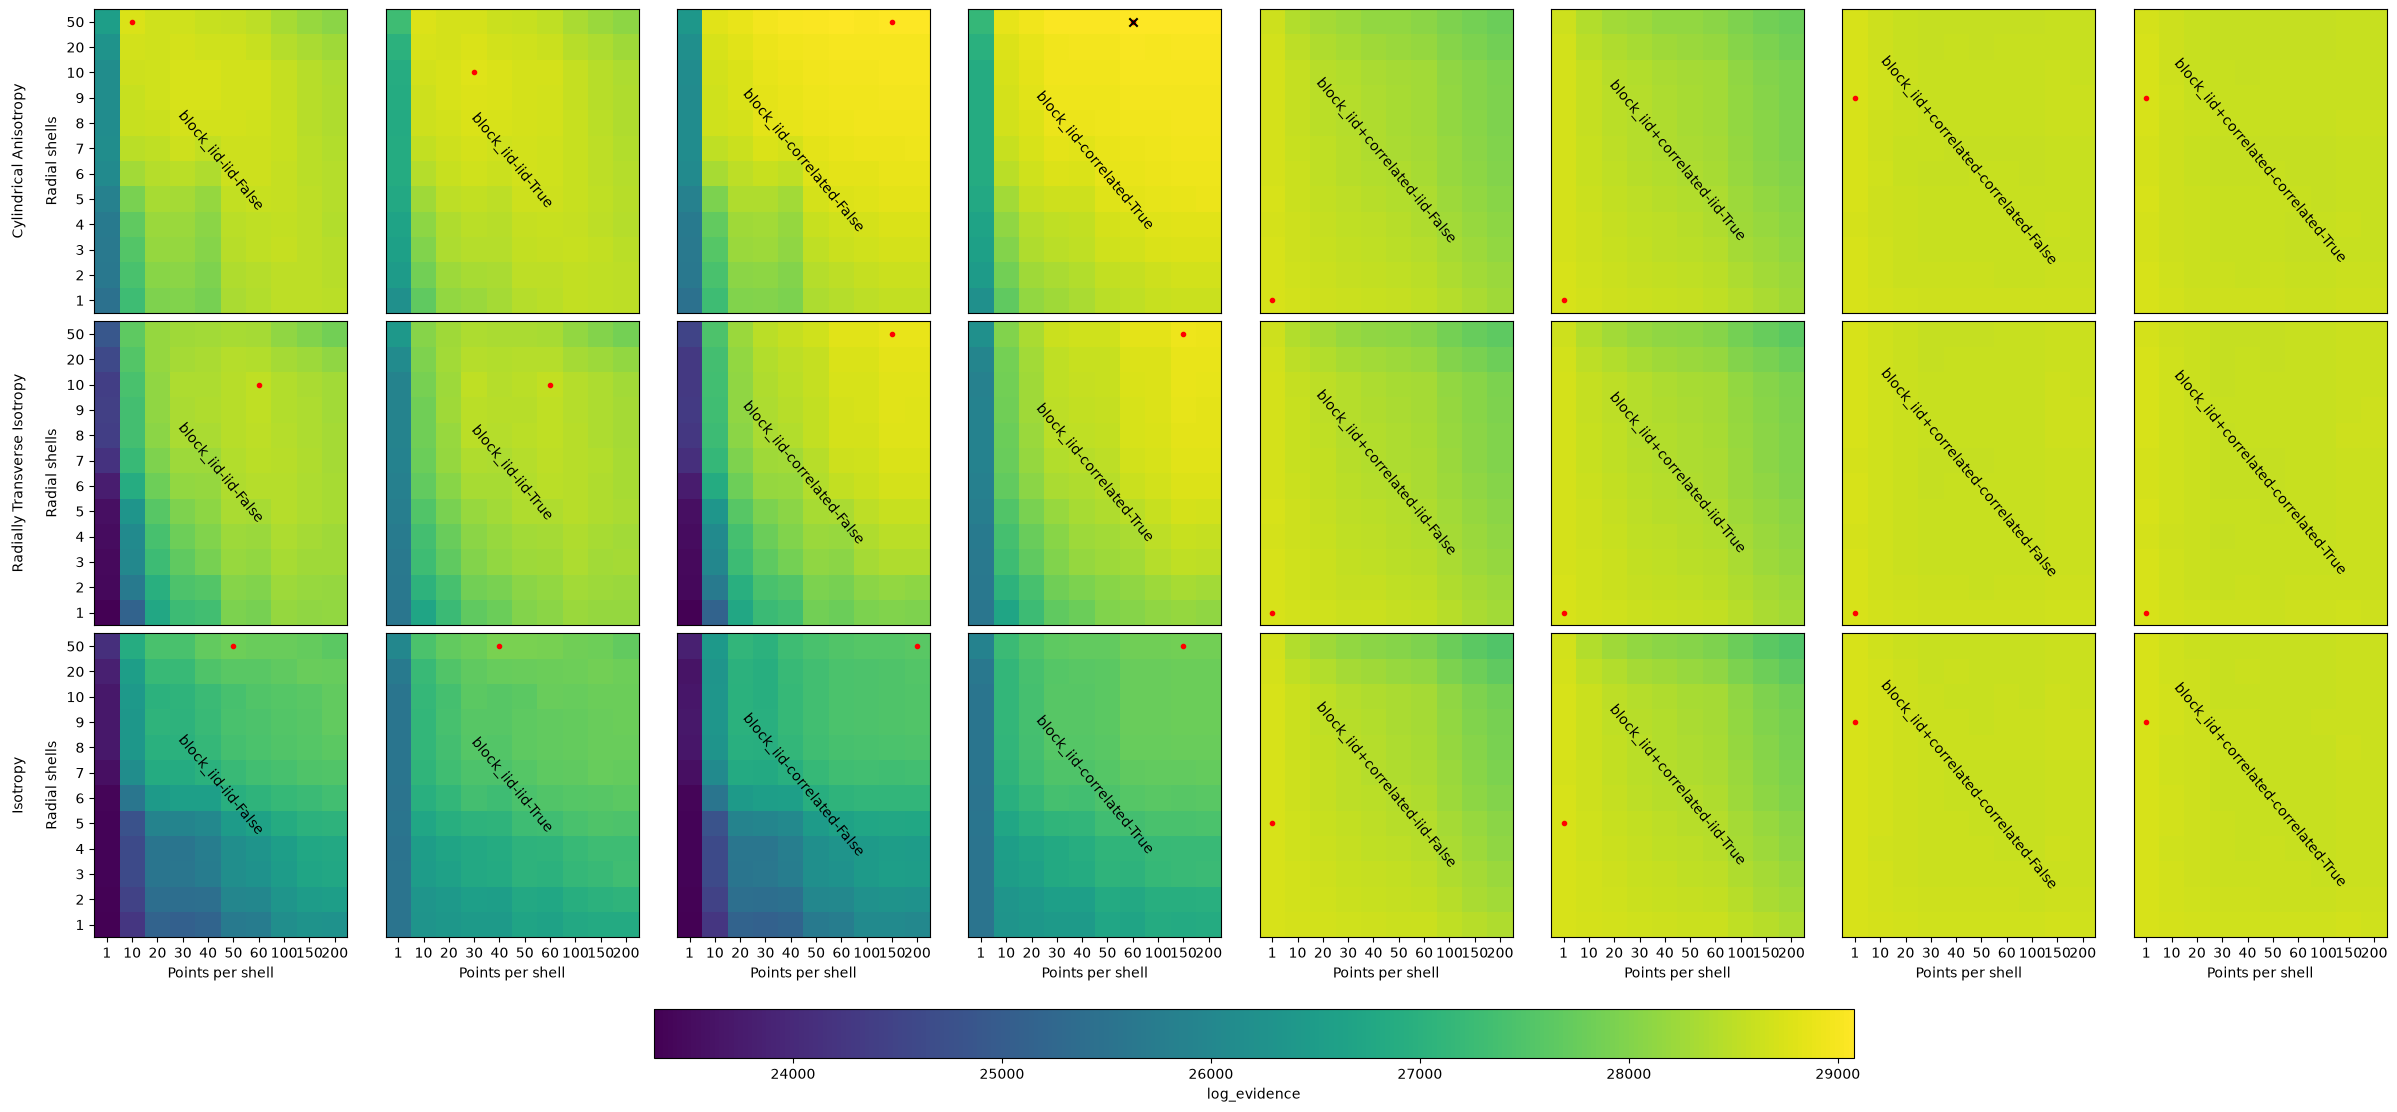

In [9]:
def grid_figsize(nrows, ncols):
    width_per_col = 3.0
    height_per_row = 3.0
    top_bottom_margin = 0.8

    width = ncols * width_per_col
    height = nrows * height_per_row + top_bottom_margin
    return (width, height)

grids = all_grids["ln_evidence"]
nrows = len(cfg_options["forward"])
ncols = (
    len(cfg_options["noise"])
    * len(cfg_options["prior"])
    * len(cfg_options["ssi_ak_bias"])
)
fig, axs = plt.subplots(
    nrows, ncols, figsize=grid_figsize(nrows, ncols), layout="constrained"
)
norm = plt.Normalize(
    min(np.min(g) for g in grids.values()), max(np.max(g) for g in grids.values())
)
for r, forward in enumerate(cfg_options["forward"]):
    c = 0
    for cfg in product(*cfg_options.values()):
        hypothesis_group = HypothesisGroup(*cfg)
        if hypothesis_group.forward != forward:
            continue
        cfg_str = "-".join(str(c) for c in cfg)
        ax = axs[r, c]
        grid = grids[hypothesis_group]
        ax.imshow(grid, origin="lower", norm=norm)
        ax.text(
            0.5,
            0.5,
            hypothesis_group.str_without("forward"),
            rotation=-np.degrees(np.atan(grid.shape[0] / grid.shape[1])),
            transform=ax.transAxes,
            ha="center",
            va="center"
        )
        ax.set_yticks([], [])
        ax.set_xticks([], [])

        mx = np.unravel_index(np.argmax(grid), grid.shape)
        ax.scatter(mx[1], mx[0], c="r", marker=".")

        if max_ln_z_hypo_group == hypothesis_group:
            ax.scatter(
                lat_res_index_map[max_ln_z["lat_res"]],
                rad_res_index_map[max_ln_z["rad_res"]],
                color="k",
                marker="x",
            )

        c += 1

_full_forward = {
    "CA": "Cylindrical Anisotropy",
    "RTI": "Radially Transverse Isotropy",
    "I": "Isotropy",
}
for ax, fwd in zip(axs[:, 0], cfg_options["forward"]):
    ax.set_ylabel(f"{_full_forward[fwd]}\n\nRadial shells")
    ax.set_yticks(list(rad_res_index_map.values()), list(rad_res_index_map.keys()))
for ax in axs[-1]:
    ax.set_xlabel("Points per shell")
    ax.set_xticks(list(lat_res_index_map.values()), list(lat_res_index_map.keys()))

cbar_ax = fig.add_axes((0.27, -0.075, 0.5, 0.05))
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm, "viridis"),
    cax=cbar_ax,
    orientation="horizontal",
    label="log_evidence",
)

In [10]:
subdf = df.drop(columns=["mahalanobis_total", "mahalanobis_ssi_ak", "mahalanobis_ssi_ak_comp"])
ds = subdf.set_index(
    ["forward", "noise", "prior", "ssi_ak_bias", "rad_res", "lat_res"]
).to_xarray()


In [13]:
def log_marginal_evidence(
    ln_evidence: xr.DataArray,
    ln_priors: Mapping[str, xr.DataArray],
    conditioned_on: Mapping[str, object] | None = None,
    marginalise: tuple[str, ...] | None = None,
) -> xr.DataArray:
    """
    Calculate

        log p(d | conditioned_on)

    by marginalising over every unconditioned model dimension.

    Parameters
    ----------
    ln_evidence
        DataArray with dimensions such as
        (D, A, B, M, R_lat, R_rad).

    ln_priors
        Mapping from each model dimension to its log prior.
        Each prior should be a 1-D DataArray defined on that dimension.

    conditioned_on
        Values to condition on, e.g.
        {"B": True}
        or
        {"D": "correlated", "M": "CA"}.
    """
    conditioned_on = conditioned_on or {}
    da = ln_evidence.sel(conditioned_on)

    if marginalise is None:
        marginalise = tuple(str(dim) for dim in da.dims if dim not in conditioned_on)

    for dim in marginalise:
        da = da + ln_priors[dim]

    return da.reduce(logsumexp, dim=marginalise)


def uniform_discrete_log_prior(
    parameter_values: xr.DataArray,
) -> xr.DataArray:
    """
    Construct a log prior that is uniform over n discrete values.
    """
    n = parameter_values.size

    return xr.DataArray(
        np.full(n, -np.log(n)),
        dims=parameter_values.dims,
        coords=parameter_values.coords,
    )


def uniform_log_prior(
    parameter_values: xr.DataArray,
    transform=lambda x: x,
) -> xr.DataArray:
    """
    Construct a log prior that is uniform in

        q = transform(parameter_values),

    using trapezoidal quadrature over the sampled grid.
    """
    x = np.asarray(parameter_values.values, dtype=float)
    q = np.asarray(transform(x), dtype=float)

    order = np.argsort(q)
    q_sorted = q[order]

    if q_sorted.size < 2:
        raise ValueError("Need at least two grid points.")

    w_sorted = np.empty_like(q_sorted)

    w_sorted[0] = 0.5 * (q_sorted[1] - q_sorted[0])
    w_sorted[-1] = 0.5 * (q_sorted[-1] - q_sorted[-2])

    if q_sorted.size > 2:
        w_sorted[1:-1] = 0.5 * (q_sorted[2:] - q_sorted[:-2])

    w = np.empty_like(w_sorted)
    w[order] = w_sorted

    w /= w.sum()

    return xr.DataArray(
        np.log(w),
        dims=parameter_values.dims,
        coords=parameter_values.coords,
    )


ln_priors = {
    "forward": uniform_discrete_log_prior(ds["forward"]),
    "noise": uniform_discrete_log_prior(ds["noise"]),
    "prior": uniform_discrete_log_prior(ds["prior"]),
    "ssi_ak_bias": uniform_discrete_log_prior(ds["ssi_ak_bias"]),

    "rad_res": uniform_log_prior(
        ds["rad_res"],
        lambda n: 1.0 / n,
    ),

    "lat_res": uniform_log_prior(
        ds["lat_res"],
        lambda n: 1.0 / n,
    ),
}

lme = partial(log_marginal_evidence, ds["ln_evidence"], ln_priors)

In [14]:
print("Bayes Factors:")
print(
    f"ssi_ak_bias vs no bias: {lme({'ssi_ak_bias': True}).values - lme({'ssi_ak_bias': False}).values}"
)
print(
    f"correlated prior vs iid prior: {lme({'prior': 'correlated'}).values - lme({'prior': 'iid'}).values}"
)
print(
    f"correlated likelihood vs i likelihood: {lme({'noise': 'block_iid+correlated'}).values - lme({'noise': 'block_iid'}).values}"
)
print()
print(f"CA vs RTI: {lme({'forward': 'CA'}).values - lme({'forward': 'RTI'}).values}")
print(f"CA vs ISO: {lme({'forward': 'CA'}).values - lme({'forward': 'I'}).values}")
print(f"RTI vs ISO: {lme({'forward': 'RTI'}).values - lme({'forward': 'I'}).values}")

Bayes Factors:
ssi_ak_bias vs no bias: 10.046048228297877
correlated prior vs iid prior: 284.3752143314232
correlated likelihood vs i likelihood: -336.2254640835199

CA vs RTI: 152.1194192022449
CA vs ISO: 336.2331314634939
RTI vs ISO: 184.11371226124902


In [18]:
lme(marginalise=("prior", "ssi_ak_bias", "lat_res", "rad_res"))

<xarray.DataArray (forward: 3, noise: 2)> Size: 48B
array([[29066.14525496, 28724.39995045],
       [27907.09931384, 28729.9121235 ],
       [28914.02583576, 28724.30170159]])
Coordinates:
  * forward  (forward) object 24B 'CA' 'I' 'RTI'
  * noise    (noise) object 16B 'block_iid' 'block_iid+correlated'